<a href="https://colab.research.google.com/github/MasudRana2406/Generative-modelling-case-study/blob/main/Generative_modelling_case_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Generative Modelling Case Study**

# Part 1: Building and Understanding GANs from Scratch

In [19]:
# Import Necessary Libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch import nn
import math
import matplotlib.pyplot as plt


import torch.optim as optim
import torch.nn as nn

import torch
from torch.utils.data import DataLoader
from torchvision import transforms

torch.manual_seed(24)

## Task 1: Reproduce the sine-wave GAN .

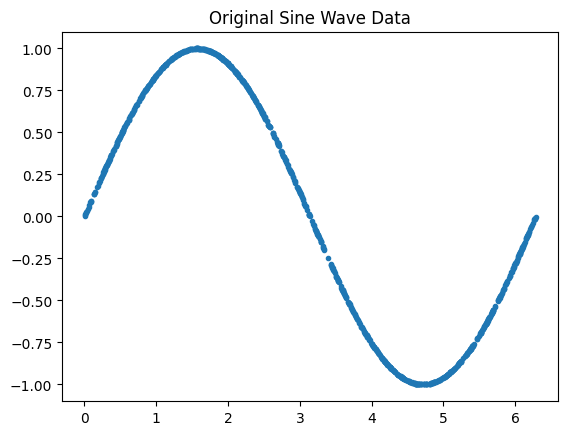

In [ ]:
train_data_length = 1024

train_data = torch.zeros((train_data_length, 2))
train_data[:, 0] = 2.0 * math.pi * torch.rand(train_data_length)
train_data[:, 1] = torch.sin(train_data[:, 0])

train_labels = torch.zeros(train_data_length)
train_set = [(train_data[i], train_labels[i]) for i in range(train_data_length)]

# Plot
plt.plot(train_data[:, 0], train_data[:, 1], ".")
plt.title("Original Sine Wave Data")
plt.show()


## DataLoader

In [ ]:
batch_size = 32

train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=batch_size, shuffle=True
)

## Discriminator

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

discriminator = Discriminator()

## Generator

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        return self.model(x)

generator = Generator()

## Hyperparameters

In [ ]:
lr = 0.001
num_epochs = 2000
loss_function = nn.BCELoss()

optimizer_discriminator = torch.optim.Adam(discriminator.parameters(), lr=lr)
optimizer_generator = torch.optim.Adam(generator.parameters(), lr=lr)

## Training Loop

In [ ]:
for epoch in range(num_epochs):
    for n, (real_samples, _) in enumerate(train_loader):


        # Train Discriminator

        real_labels = torch.ones((batch_size, 1))
        latent_space = torch.randn((batch_size, 2))
        fake_samples = generator(latent_space)
        fake_labels = torch.zeros((batch_size, 1))

        all_samples = torch.cat((real_samples, fake_samples))
        all_labels = torch.cat((real_labels, fake_labels))

        discriminator.zero_grad()
        output = discriminator(all_samples)
        loss_d = loss_function(output, all_labels)
        loss_d.backward()
        optimizer_discriminator.step()


        # Train Generator

        latent_space = torch.randn((batch_size, 2))

        generator.zero_grad()
        fake_samples = generator(latent_space)
        output = discriminator(fake_samples)

        loss_g = loss_function(output, real_labels)
        loss_g.backward()
        optimizer_generator.step()

    if epoch % 200 == 0:
        print(f"Epoch {epoch} | Loss D: {loss_d:.4f} | Loss G: {loss_g:.4f}")

Epoch 0 | Loss D: 0.1758 | Loss G: 2.7769
Epoch 200 | Loss D: 0.6385 | Loss G: 0.7296
Epoch 400 | Loss D: 0.6062 | Loss G: 0.9913
Epoch 600 | Loss D: 0.7152 | Loss G: 0.7077
Epoch 800 | Loss D: 0.6873 | Loss G: 0.6898
Epoch 1000 | Loss D: 0.7118 | Loss G: 0.7927
Epoch 1200 | Loss D: 0.6935 | Loss G: 1.3166
Epoch 1400 | Loss D: 0.6936 | Loss G: 0.6866
Epoch 1600 | Loss D: 0.5611 | Loss G: 1.1344
Epoch 1800 | Loss D: 0.6751 | Loss G: 0.7097


## Visual Comparison

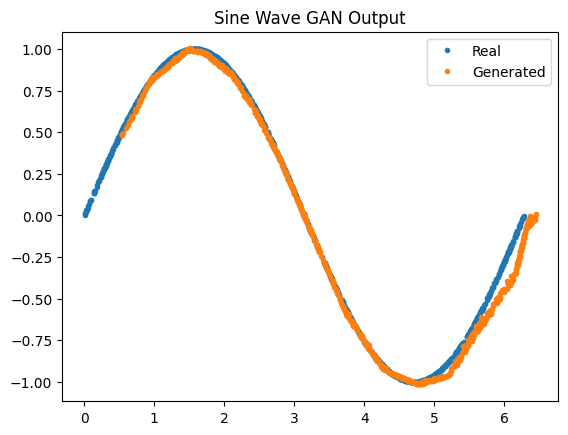

In [ ]:
latent_space = torch.randn(1000, 2)
generated_samples = generator(latent_space).detach().numpy()

plt.plot(train_data[:, 0], train_data[:, 1], ".", label="Real")
plt.plot(generated_samples[:, 0], generated_samples[:, 1], ".", label="Generated")
plt.legend()
plt.title("Sine Wave GAN Output")
plt.show()

## Task 2: Create and model a new 2D distribution (A 2D spiral )

In [32]:
def generate_spiral(n_samples=2000):
    theta = np.linspace(0, 4 * np.pi, n_samples)
    r = theta

    x = r * np.cos(theta)
    y = r * np.sin(theta)

    data = np.stack([x, y], axis=1)

    # Normalize for stable GAN training
    data = data / np.max(np.abs(data))

    return torch.tensor(data, dtype=torch.float32)

real_data = generate_spiral()


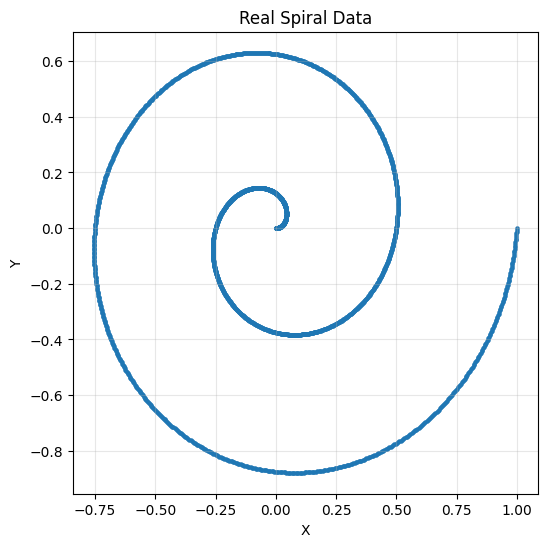

In [109]:
# Convert tensor to numpy (for plotting)
real_np = real_data.numpy()

plt.figure(figsize=(6,6))
plt.scatter(real_np[:, 0], real_np[:, 1], s=5)
plt.title("Real Spiral Data")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(alpha=0.3)
plt.show()

## Generator

In [33]:
class Generator(nn.Module):
    def __init__(self, noise_dim=2):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(noise_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, z):
        return self.model(z)

## Discriminator

In [34]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

## Initialize Models

In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
g_optimizer = torch.optim.Adam(G.parameters(), lr=0.001)
d_optimizer = torch.optim.Adam(D.parameters(), lr=0.001)

## Training Loop

In [36]:
epochs = 3000
batch_size = 128
noise_dim = 2

real_data = real_data.to(device)

for epoch in range(epochs):
    # Sample real data
    idx = torch.randint(0, real_data.size(0), (batch_size,))
    real = real_data[idx]

    # Generate fake data
    z = torch.randn(batch_size, noise_dim).to(device)
    fake = G(z)

    # Labels
    real_labels = torch.ones(batch_size, 1).to(device)
    fake_labels = torch.zeros(batch_size, 1).to(device)

    # Train Discriminator
    d_loss_real = criterion(D(real), real_labels)
    d_loss_fake = criterion(D(fake.detach()), fake_labels)
    d_loss = d_loss_real + d_loss_fake

    d_optimizer.zero_grad()
    d_loss.backward()
    d_optimizer.step()

    # Train Generator
    g_loss = criterion(D(fake), real_labels)

    g_optimizer.zero_grad()
    g_loss.backward()
    g_optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

Epoch 0 | D Loss: 1.4026 | G Loss: 0.6312
Epoch 500 | D Loss: 1.4386 | G Loss: 0.6531
Epoch 1000 | D Loss: 1.4509 | G Loss: 0.8617
Epoch 1500 | D Loss: 1.4624 | G Loss: 0.6483
Epoch 2000 | D Loss: 1.4303 | G Loss: 0.7181
Epoch 2500 | D Loss: 1.2610 | G Loss: 0.6644


## Visual Comparison between original & generated sample

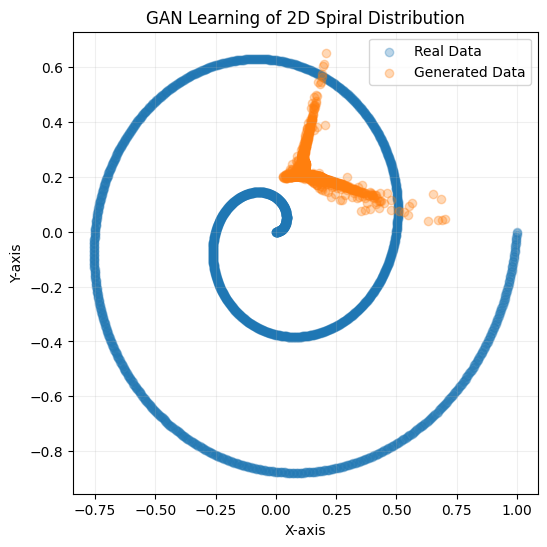

In [40]:
def plot_results(G, real_data):
    G.eval()
    with torch.no_grad():
        z = torch.randn(2000, noise_dim).to(device)
        fake = G(z).cpu().numpy()

    real = real_data.cpu().numpy()

    fig, ax = plt.subplots(figsize=(6,6))

    ax.scatter(real[:,0], real[:,1], alpha=0.3, label="Real Data")
    ax.scatter(fake[:,0], fake[:,1], alpha=0.3, label="Generated Data")

    ax.set_title("GAN Learning of 2D Spiral Distribution")
    ax.set_xlabel("X-axis")
    ax.set_ylabel("Y-axis")
    ax.legend()
    ax.grid(alpha=0.2)

    plt.show()
plot_results(G, real_data)

## Task 3: Modify the GAN architecture

## Improved Models

In [41]:
noise_dim = 2

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim, 64),
            nn.ReLU(),

            nn.Linear(64, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 2)
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),

            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.net(x)


## Initialize Model

In [42]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()

g_optimizer = optim.Adam(G.parameters(), lr=0.0005, betas=(0.5, 0.999))
d_optimizer = optim.Adam(D.parameters(), lr=0.0005, betas=(0.5, 0.999))

real_data = real_data.to(device)

## Training

In [43]:
epochs = 4000
batch_size = 128

g_losses = []
d_losses = []

for epoch in range(epochs):

    # Sample real data
    idx = torch.randint(0, real_data.size(0), (batch_size,))
    real = real_data[idx]

    # Add small noise (important)
    real = real + 0.02 * torch.randn_like(real)

    # Generate fake
    z = torch.randn(batch_size, noise_dim).to(device)
    fake = G(z)

    # Labels
    real_labels = torch.ones(batch_size, 1).to(device)
    fake_labels = torch.zeros(batch_size, 1).to(device)


    # Train Discriminator

    d_real = D(real)
    d_fake = D(fake.detach())

    d_loss_real = criterion(d_real, real_labels)
    d_loss_fake = criterion(d_fake, fake_labels)

    d_loss = d_loss_real + d_loss_fake

    d_optimizer.zero_grad()
    d_loss.backward()
    d_optimizer.step()


    # Train Generator

    g_loss_total = 0

    for _ in range(2):
        z = torch.randn(batch_size, noise_dim).to(device)
        fake = G(z)

        g_loss = criterion(D(fake), real_labels)

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        g_loss_total += g_loss.item()

    g_loss_avg = g_loss_total / 2

    # Store losses
    g_losses.append(g_loss_avg)
    d_losses.append(d_loss.item())

    # Logging
    if epoch % 500 == 0:
        print(f"Epoch {epoch} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss_avg:.4f}")

Epoch 0 | D Loss: 1.3824 | G Loss: 0.6860
Epoch 500 | D Loss: 1.3520 | G Loss: 0.9130
Epoch 1000 | D Loss: 1.3606 | G Loss: 0.6728
Epoch 1500 | D Loss: 1.3975 | G Loss: 0.6874
Epoch 2000 | D Loss: 1.3839 | G Loss: 0.7256
Epoch 2500 | D Loss: 1.3874 | G Loss: 0.6995
Epoch 3000 | D Loss: 1.3702 | G Loss: 0.6994
Epoch 3500 | D Loss: 1.3879 | G Loss: 0.7201


## Visual Comparison between original & generated sample

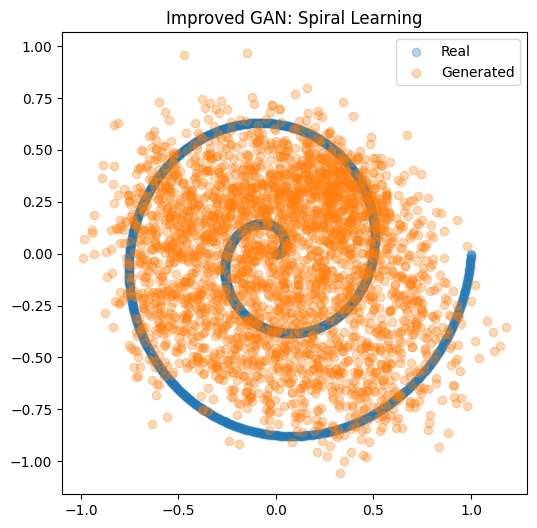

In [ ]:
def plot_results(G, real_data):
    G.eval()
    with torch.no_grad():
        z = torch.randn(3000, noise_dim).to(device)
        fake = G(z).cpu().numpy()

    real = real_data.cpu().numpy()

    plt.figure(figsize=(6,6))
    plt.scatter(real[:,0], real[:,1], alpha=0.3, label="Real")
    plt.scatter(fake[:,0], fake[:,1], alpha=0.3, label="Generated")
    plt.legend()
    plt.title("Improved GAN: Spiral Learning")
    plt.grid(alpha=0.2)
    plt.show()

plot_results(G, real_data)

# Part 2: Real-World GAN Applications
## Part 2.1: Blood Cell Microscope Imaging with MedMNIST

In [ ]:
!pip install medmnist

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

from torch.utils.data import DataLoader
import medmnist
from medmnist import INFO, Evaluator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 3.8 MB/s eta 0:00:00


### Load & Explore BloodMNIST Dataset

In [ ]:
data_flag = 'bloodmnist'
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

# Transform
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

# Load dataset
train_dataset = DataClass(split='train', transform=transform, download=True)
test_dataset = DataClass(split='test', transform=transform, download=True)

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

# Info
print("Classes:", info['label'])
print("Number of training samples:", len(train_dataset))

100%|██████████| 35.5M/35.5M [00:02<00:00, 15.1MB/s]


Classes: {'0': 'basophil', '1': 'eosinophil', '2': 'erythroblast', '3': 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', '4': 'lymphocyte', '5': 'monocyte', '6': 'neutrophil', '7': 'platelet'}
Number of training samples: 11959


### Visualize Samples

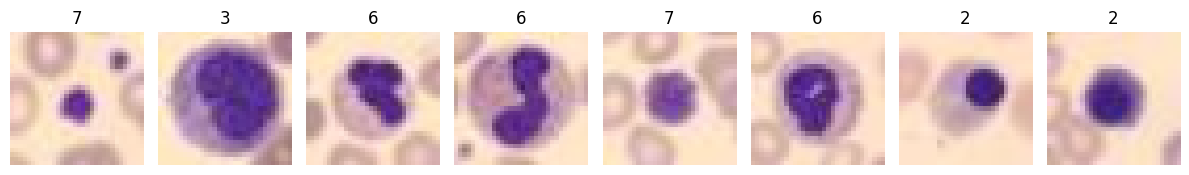

In [ ]:
import matplotlib.pyplot as plt

def show_images(dataset, n=8):
    fig, axes = plt.subplots(1, n, figsize=(12, 4))

    for i in range(n):
        img, label = dataset[i]

        # (C, H, W) → (H, W, C)
        img = img.permute(1, 2, 0).numpy()

        # denormalize [-1,1] → [0,1]
        img = (img * 0.5) + 0.5
        img = img.clip(0, 1)

        axes[i].imshow(img)
        axes[i].set_title(str(label.squeeze().item()))
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

show_images(train_dataset)

## DCGAN Architecture
Generator

In [ ]:
class Generator(nn.Module):
    def __init__(self, noise_dim=100):
        super().__init__()

        self.net = nn.Sequential(
            nn.ConvTranspose2d(noise_dim, 256, 4, 1, 0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        # ensure correct shape
        x = x.view(x.size(0), x.size(1), 1, 1)
        return self.net(x)

Discriminator

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),

            # fixed for 32x32 input
            nn.Linear(256 * 4 * 4, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

## Training Setup

In [ ]:
noise_dim = 100

# ensure device exists
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G = Generator(noise_dim).to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()

optimizer_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

## Train DCGAN

In [ ]:
num_epochs = 10

g_losses, d_losses = [], []

for epoch in range(num_epochs):

    g_epoch_loss = 0
    d_epoch_loss = 0
    n_batches = 0

    for real_imgs, _ in train_loader:

        real_imgs = real_imgs.to(device)
        batch_size = real_imgs.size(0)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # Train Discriminator

        z = torch.randn(batch_size, noise_dim, 1, 1).to(device)
        fake_imgs = G(z)

        real_loss = criterion(D(real_imgs), real_labels)
        fake_loss = criterion(D(fake_imgs.detach()), fake_labels)

        d_loss = real_loss + fake_loss

        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()


        # Train Generator

        z = torch.randn(batch_size, noise_dim, 1, 1).to(device)
        fake_imgs = G(z)

        g_loss = criterion(D(fake_imgs), real_labels)

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

        # accumulate epoch loss
        g_epoch_loss += g_loss.item()
        d_epoch_loss += d_loss.item()
        n_batches += 1

    # store averaged loss per epoch
    g_losses.append(g_epoch_loss / n_batches)
    d_losses.append(d_epoch_loss / n_batches)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"D Loss: {d_losses[-1]:.4f}, G Loss: {g_losses[-1]:.4f}")

Epoch [1/10] D Loss: 0.5508, G Loss: 3.2986
Epoch [2/10] D Loss: 0.5447, G Loss: 3.2687
Epoch [3/10] D Loss: 0.5709, G Loss: 2.7443
Epoch [4/10] D Loss: 0.6961, G Loss: 2.7350
Epoch [5/10] D Loss: 0.4720, G Loss: 2.8367
Epoch [6/10] D Loss: 0.7300, G Loss: 2.3923
Epoch [7/10] D Loss: 0.6120, G Loss: 2.7342
Epoch [8/10] D Loss: 0.5588, G Loss: 2.6897
Epoch [9/10] D Loss: 0.3768, G Loss: 3.0869
Epoch [10/10] D Loss: 0.7380, G Loss: 2.2788


## Loss Curve

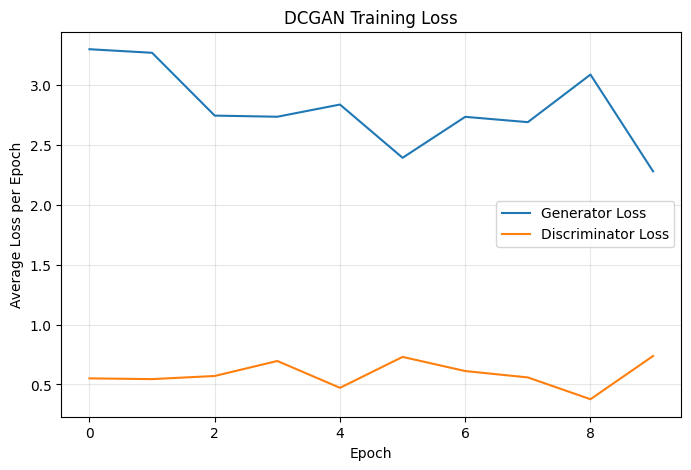

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(g_losses, label="Generator Loss")
plt.plot(d_losses, label="Discriminator Loss")

plt.legend()
plt.title("DCGAN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Average Loss per Epoch")

plt.grid(alpha=0.3)
plt.show()

## Generate Images

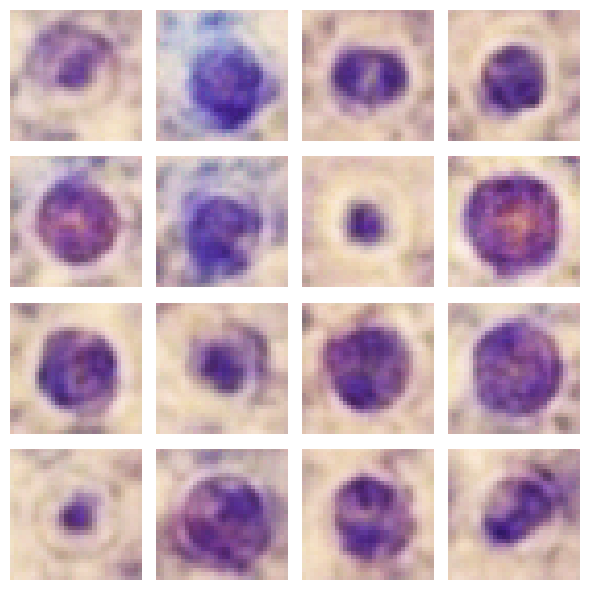

In [ ]:
def generate_images(G, n=16):
    G.eval()

    z = torch.randn(n, noise_dim, 1, 1).to(device)

    with torch.no_grad():
        fake_imgs = G(z).cpu()

    # denormalize [-1,1] → [0,1]
    fake_imgs = (fake_imgs + 1) / 2
    fake_imgs = fake_imgs.clamp(0, 1)

    # dynamic grid (safer)
    grid_size = int(n ** 0.5)
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(6,6))

    axes = axes.flatten()

    for i, ax in enumerate(axes):
        img = fake_imgs[i].permute(1, 2, 0)
        ax.imshow(img)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

    G.train()

generate_images(G)

## Visual Comparison

In [ ]:
def compare_real_fake(G, dataloader, n=8):

    G.eval()


    # REAL IMAGES

    real_imgs, _ = next(iter(dataloader))
    real_imgs = real_imgs[:n]


    # FAKE IMAGES

    z = torch.randn(n, noise_dim, 1, 1).to(device)

    with torch.no_grad():
        fake_imgs = G(z).cpu()

    # Denormalize

    real_imgs = ((real_imgs + 1) / 2).clamp(0, 1)
    fake_imgs = ((fake_imgs + 1) / 2).clamp(0, 1)


    # Plot

    fig, axes = plt.subplots(2, n, figsize=(2*n, 4))

    for i in range(n):

        axes[0, i].imshow(real_imgs[i].permute(1, 2, 0))
        axes[0, i].set_title("Real")
        axes[0, i].axis('off')

        axes[1, i].imshow(fake_imgs[i].permute(1, 2, 0))
        axes[1, i].set_title("Fake")
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

    G.train()

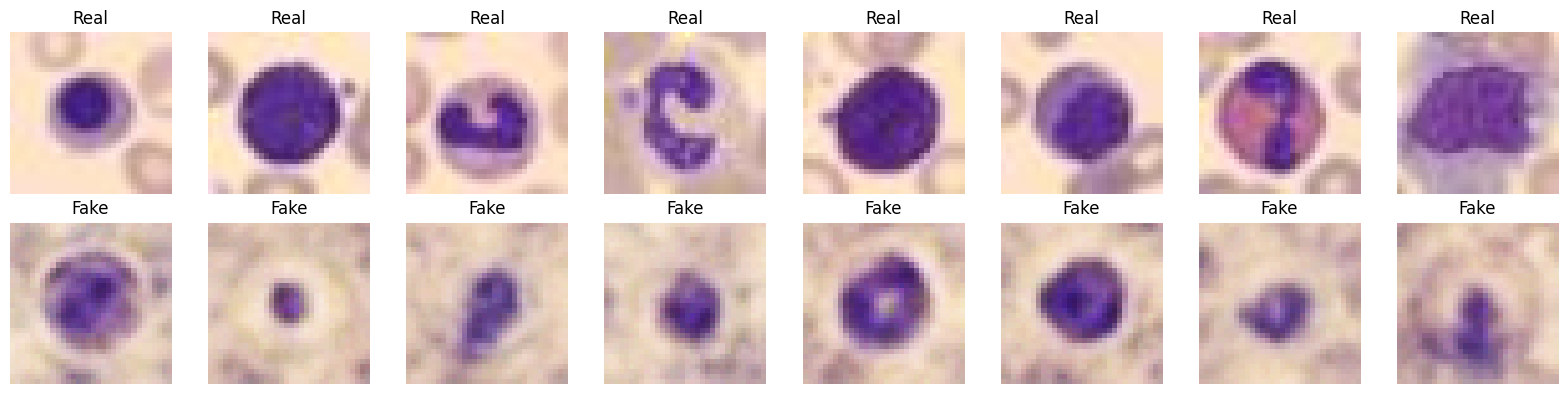

In [ ]:
compare_real_fake(G, train_loader)

## Quantitative Evaluation (FID Score)

In [ ]:
!pip install pytorch-fid

## Save images (REAL + FAKE)

In [ ]:
import os
import torch
from torchvision.utils import save_image

os.makedirs("real_images", exist_ok=True)
os.makedirs("fake_images", exist_ok=True)


# SAVE REAL IMAGES

count = 0

for imgs, _ in train_loader:
    imgs = ((imgs + 1) / 2).clamp(0, 1)

    for img in imgs:
        save_image(img.cpu(), f"real_images/{count}.png")
        count += 1

        if count >= 1000:
            break

    if count >= 1000:
        break

# SAVE FAKE IMAGES

G.eval()

z = torch.randn(1000, noise_dim, 1, 1).to(device)

with torch.no_grad():
    fake_imgs = G(z).cpu()

fake_imgs = ((fake_imgs + 1) / 2).clamp(0, 1)

for i, img in enumerate(fake_imgs):
    save_image(img, f"fake_images/{i}.png")

G.train()

Generator(
  (net): Sequential(
    (0): ConvTranspose2d(100, 256, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): Tanh()
  )
)

## Compute FID

In [ ]:
from pytorch_fid import fid_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# compute FID
fid = fid_score.calculate_fid_given_paths(
    ['real_images', 'fake_images'],
    batch_size=50,
    device=device,
    dims=2048
)

print("FID Score:", fid)

Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth


100%|██████████| 91.2M/91.2M [00:01<00:00, 82.4MB/s]
100%|██████████| 20/20 [07:10<00:00, 21.55s/it]


FID Score: 312.95278785536385


## cGAN (CONDITIONAL GAN)
Generator

In [ ]:
class CGAN_Generator(nn.Module):
    def __init__(self, noise_dim, num_classes, embed_size=100):
        super().__init__()

        self.label_emb = nn.Embedding(num_classes, embed_size)

        self.net = nn.Sequential(
            # Input: (noise + label)
            nn.ConvTranspose2d(noise_dim + embed_size, 256, 4, 1, 0),  # 4x4
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1),  # 8x8
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),   # 16x16
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 3, 4, 2, 1),     # 32x32 RGB
            nn.Tanh()
        )

    def forward(self, z, labels):
        label_embed = self.label_emb(labels).unsqueeze(2).unsqueeze(3)
        x = torch.cat([z, label_embed], dim=1)
        return self.net(x)

Discriminator

In [ ]:
class CGAN_Discriminator(nn.Module):
    def __init__(self, num_classes, embed_size=128):
        super().__init__()

        self.label_emb = nn.Embedding(num_classes, embed_size)

        self.conv = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),   # 32 → 16
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1), # 16 → 8
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, 2, 1), # 8 → 4
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
        )

        self.fc = nn.Linear(256 * 4 * 4, 1)

    def forward(self, img, labels):
        x = self.conv(img)
        x = x.view(x.size(0), -1)  # flatten

        out = self.fc(x)


        label_embed = self.label_emb(labels)
        proj = torch.sum(x * label_embed, dim=1, keepdim=True)

        return torch.sigmoid(out + proj)

## Initialize Models

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(info['label'])
noise_dim = 100

G = CGAN_Generator(noise_dim, num_classes).to(device)
D = CGAN_Discriminator(num_classes).to(device)

criterion = nn.BCELoss()

optimizer_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

## Training Loop

In [ ]:
num_epochs = 10

g_losses = []
d_losses = []

for epoch in range(num_epochs):

    g_epoch_loss = 0
    d_epoch_loss = 0
    n_batches = 0

    for real_imgs, labels in train_loader:

        real_imgs = real_imgs.to(device)
        labels = labels.squeeze().long().to(device)

        batch_size = real_imgs.size(0)

        # Label smoothing
        real_targets = torch.ones(batch_size, 1).to(device) * 0.9
        fake_targets = torch.zeros(batch_size, 1).to(device)


        # Train Discriminator

        z = torch.randn(batch_size, noise_dim, 1, 1).to(device)
        fake_imgs = G(z, labels)

        d_real = D(real_imgs, labels)
        d_fake = D(fake_imgs.detach(), labels)

        d_loss = criterion(d_real, real_targets) + criterion(d_fake, fake_targets)

        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()


        # Train Generator

        z = torch.randn(batch_size, noise_dim, 1, 1).to(device)
        fake_imgs = G(z, labels)

        g_loss = criterion(D(fake_imgs, labels), real_targets)

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

        g_epoch_loss += g_loss.item()
        d_epoch_loss += d_loss.item()
        n_batches += 1

    g_losses.append(g_epoch_loss / n_batches)
    d_losses.append(d_epoch_loss / n_batches)

    print(f"Epoch {epoch+1}/{num_epochs} | D: {d_losses[-1]:.4f} | G: {g_losses[-1]:.4f}")

Epoch 1/10 | D: 1.5313 | G: 0.7762
Epoch 2/10 | D: 1.4383 | G: 0.7576
Epoch 3/10 | D: 1.3965 | G: 0.7772
Epoch 4/10 | D: 1.3839 | G: 0.7833
Epoch 5/10 | D: 1.3814 | G: 0.7872
Epoch 6/10 | D: 1.3772 | G: 0.7866
Epoch 7/10 | D: 1.3776 | G: 0.7936
Epoch 8/10 | D: 1.3788 | G: 0.8012
Epoch 9/10 | D: 1.3813 | G: 0.7909
Epoch 10/10 | D: 1.3805 | G: 0.7916


## Plot Loss

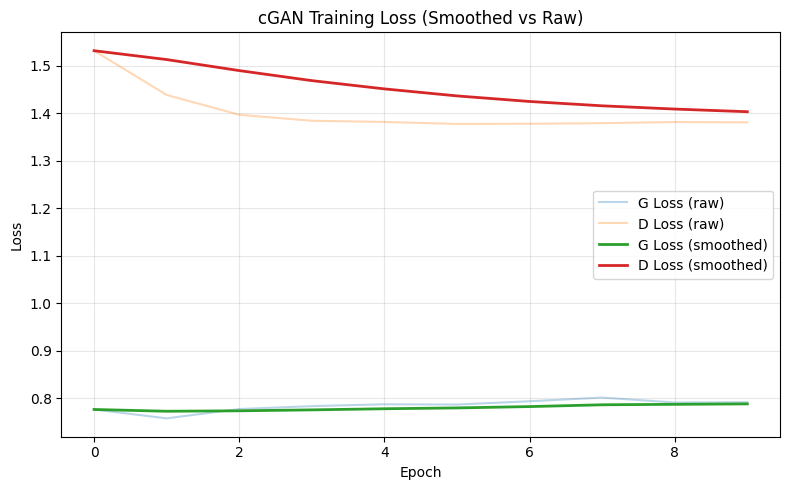

In [ ]:
def smooth_curve(values, weight=0.8):
    smoothed = []
    last = values[0]
    for v in values:
        last = last * weight + (1 - weight) * v
        smoothed.append(last)
    return smoothed

g_smooth = smooth_curve(g_losses)
d_smooth = smooth_curve(d_losses)

plt.figure(figsize=(8,5))

plt.plot(g_losses, alpha=0.3, label="G Loss (raw)")
plt.plot(d_losses, alpha=0.3, label="D Loss (raw)")

plt.plot(g_smooth, linewidth=2, label="G Loss (smoothed)")
plt.plot(d_smooth, linewidth=2, label="D Loss (smoothed)")

plt.legend()
plt.title("cGAN Training Loss (Smoothed vs Raw)")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

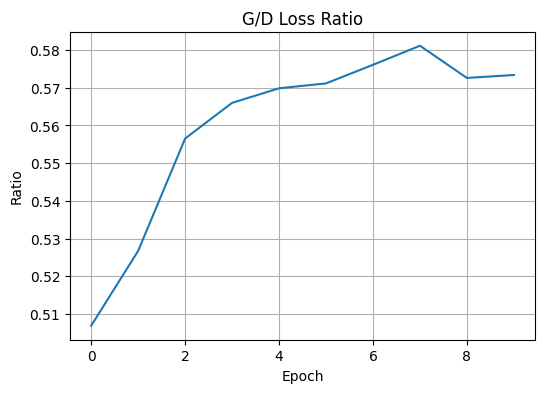

In [ ]:
ratio = np.array(g_losses) / np.array(d_losses)

plt.figure(figsize=(6,4))
plt.plot(ratio)
plt.title("G/D Loss Ratio")
plt.xlabel("Epoch")
plt.ylabel("Ratio")
plt.grid()
plt.show()

## Generate Specific Class Images

In [ ]:
def generate_class_images(G, class_label, n=8):
    G.eval()

    labels = torch.full((n,), class_label, dtype=torch.long).to(device)
    z = torch.randn(n, noise_dim, 1, 1).to(device)

    with torch.no_grad():
        fake_imgs = G(z, labels).cpu()

    fake_imgs = ((fake_imgs + 1) / 2).clamp(0, 1)

    plt.figure(figsize=(10, 2))

    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(fake_imgs[i].permute(1, 2, 0))
        plt.axis('off')

    plt.suptitle(f"Generated Class {class_label}")
    plt.tight_layout()
    plt.show()

    G.train()

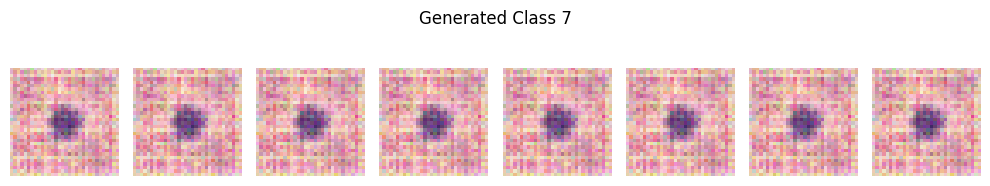

In [ ]:
generate_class_images(G, class_label=7)

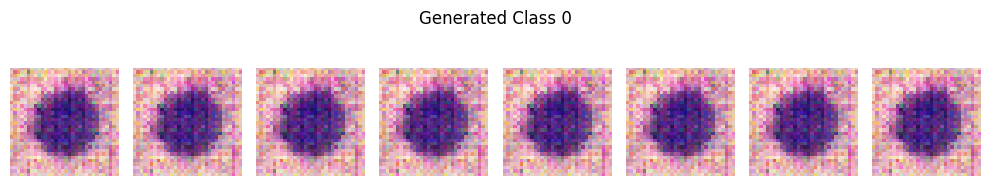

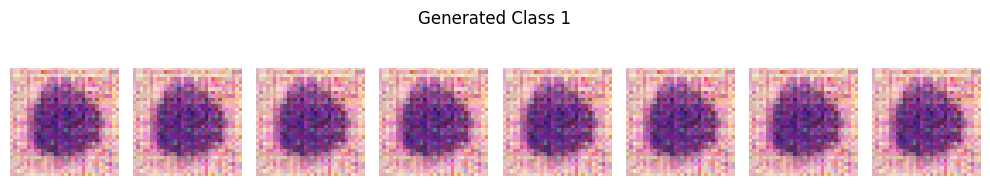

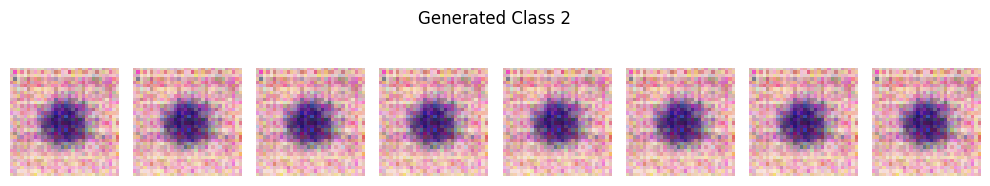

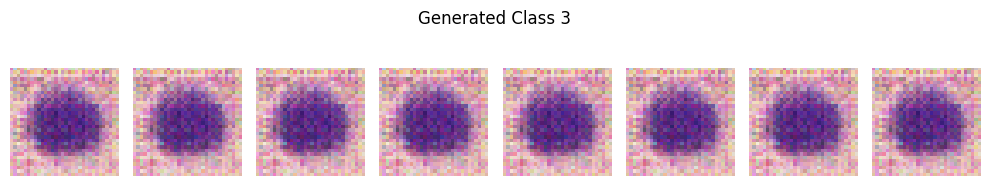

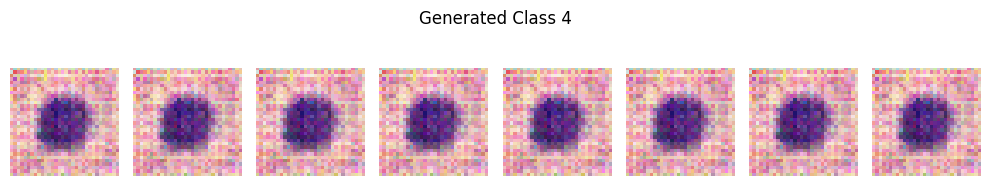

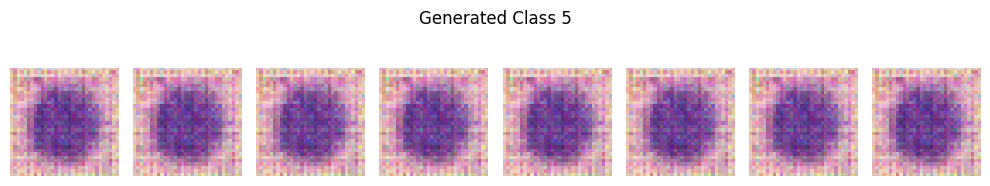

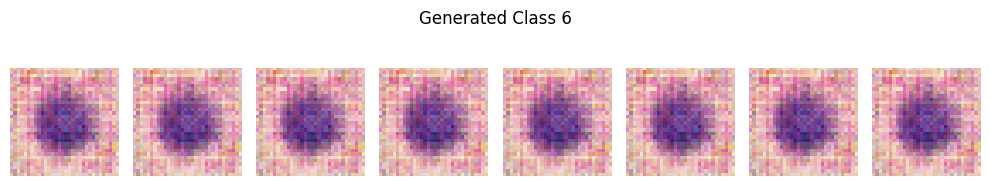

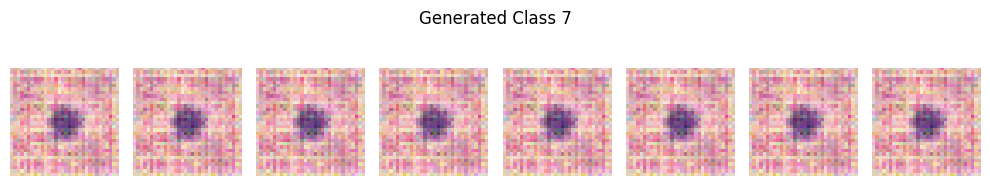

In [ ]:
for i in range(num_classes):
    generate_class_images(G, class_label=i)

## Part 2.2: Cybersecurity – Synthetic Traffic with CICIDS 2017

##  Load & Combine CSVs from ZIP

In [3]:
import zipfile

zip_path = "/content/drive/MyDrive/2nd Year/Semester B/Assignment/Generative modelling case study (40%)/CICIDS 2017 (DDoS and BENIGN labels) .zip"

dfs = []

with zipfile.ZipFile(zip_path) as z:
    for file in z.namelist():
        if file.endswith(".csv"):
            print("Loading:", file)
            with z.open(file) as f:
                df = pd.read_csv(f)
                dfs.append(df)

# Combine all days
data = pd.concat(dfs, ignore_index=True)

print("Final shape:", data.shape)
data.head()

Loading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Loading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Loading: Friday-WorkingHours-Morning.pcap_ISCX.csv
Loading: Monday-WorkingHours.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Loading: Tuesday-WorkingHours.pcap_ISCX.csv
Loading: Wednesday-workingHours.pcap_ISCX.csv
Final shape: (2830743, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


## Explore Dataset

In [4]:
# Check columns
print(data.columns)

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

In [5]:
# Check class distribution
data['Label'] = data[' Label']
data.drop(' Label', axis=1, inplace=True)
print(data['Label'].value_counts())

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [6]:
# Check missing values
print(data.isnull().sum())

 Destination Port              0
 Flow Duration                 0
 Total Fwd Packets             0
 Total Backward Packets        0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
 Idle Std                      0
 Idle Max                      0
 Idle Min                      0
Label                          0
Length: 79, dtype: int64


In [7]:
data = data.sample(n=5000, random_state=42)

In [8]:
# Basic stats
data.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03
mean,8038.101200,1.472965e+07,8.428400,8.715400,520.769200,1.227086e+04,209.615400,18.553400,58.801795,69.317041,...,4.982600,25.858400,7.825478e+04,3.549331e+04,1.406568e+05,5.844218e+04,8.375026e+06,6.021692e+05,8.828081e+06,7.910642e+06
std,18350.945121,3.345309e+07,143.860612,160.275906,2600.767464,3.637816e+05,709.893627,56.394429,188.815412,281.590381,...,97.388597,6.512114,5.405987e+05,2.827129e+05,8.177933e+05,4.925850e+05,2.355511e+07,5.173482e+06,2.447924e+07,2.321546e+07
min,0.000000,-1.000000e+00,1.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,53.000000,1.600000e+02,2.000000,1.000000,12.000000,6.000000e+00,6.000000,0.000000,6.000000,0.000000,...,0.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,80.000000,3.198450e+04,2.000000,2.000000,62.000000,1.260000e+02,38.000000,2.000000,35.000000,0.000000,...,1.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,443.000000,3.023606e+06,5.000000,4.000000,194.500000,4.562500e+02,85.000000,37.000000,50.000000,25.260389,...,2.000000,32.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,65481.000000,1.199827e+08,9449.000000,10063.000000,70306.000000,2.340090e+07,11595.000000,1983.000000,3195.727273,5184.100867,...,6167.000000,44.000000,1.100000e+07,7.213298e+06,2.160307e+07,1.100000e+07,1.194644e+08,6.680000e+07,1.194644e+08,1.194644e+08


## Load Wednesday dataset ONLY

In [9]:
zip_path = "/content/drive/MyDrive/2nd Year/Semester B/Assignment/Generative modelling case study (40%)/CICIDS 2017 (DDoS and BENIGN labels) .zip"
target_file = "Wednesday-workingHours.pcap_ISCX.csv"

with zipfile.ZipFile(zip_path) as z:
    file_list = [f for f in z.namelist() if target_file in f][0]

    with z.open(file_list) as f:
        data = pd.read_csv(f)

In [10]:
# Clean column names
data.columns = data.columns.str.strip()

print(data.shape)
print(data['Label'].value_counts())

(692703, 79)
Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64


## Filter BENIGN + DoS only

In [11]:
data = data[
    (data['Label'].str.contains("BENIGN", case=False)) |
    (data['Label'].str.contains("DoS", case=False))
].copy()

# Binary label
data['binary_label'] = data['Label'].apply(lambda x: 0 if "BENIGN" in x else 1)

print(data['Label'].value_counts())

Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Name: count, dtype: int64


## Clean + prepare features

In [12]:
# Convert all to numeric safely
for col in data.columns:
    if col not in ['Label', 'binary_label']:
        data[col] = pd.to_numeric(data[col], errors='coerce')

# Remove invalid values
data = data.replace([np.inf, -np.inf], np.nan)
data = data.dropna()

print("After cleaning:", data.shape)

After cleaning: (691395, 80)


## Feature / target split

In [13]:
X = data.drop(columns=['Label', 'binary_label'])
y = data['binary_label'].values

## Train-test split

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

data_dim = X_train.shape[1]

print("Feature dimension:", data_dim)

Feature dimension: 78


## Convert to PyTorch DataLoader

In [16]:

# Ensure correct dtype
X_tensor = torch.tensor(X_train, dtype=torch.float32)

batch_size = 256

# Important: dataset returns (features,) tuple
dataset = TensorDataset(X_tensor)

loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

## Build GAN (MLP for tabular data)

In [20]:
noise_dim = 32

class Generator(nn.Module):
    def __init__(self, data_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(noise_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, data_dim)
        )

    def forward(self, z):
        return self.net(z)

In [21]:
class Discriminator(nn.Module):
    def __init__(self, data_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(data_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),

            nn.Linear(64, 1)

        )

    def forward(self, x):
        return self.net(x)

##  Initialize model + optimizer

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G = Generator(data_dim).to(device)
D = Discriminator(data_dim).to(device)

criterion = nn.BCEWithLogitsLoss()

g_opt = torch.optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
d_opt = torch.optim.Adam(D.parameters(), lr=0.0001, betas=(0.5, 0.999))

##  Train GAN (with loss tracking)

In [24]:
num_epochs = 15

g_losses = []
d_losses = []

for epoch in range(num_epochs):

    g_epoch_loss = 0
    d_epoch_loss = 0
    n_batches = 0

    for (real,) in loader:

        real = real.to(device)
        batch_size = real.size(0)

        # Labels

        real_labels = torch.ones(batch_size, 1).to(device) * 0.9
        fake_labels = torch.zeros(batch_size, 1).to(device)


        # Train Discriminator

        z = torch.randn(batch_size, noise_dim).to(device)
        fake = G(z)

        d_real = D(real)
        d_fake = D(fake.detach())

        d_loss_real = criterion(d_real, real_labels)
        d_loss_fake = criterion(d_fake, fake_labels)

        d_loss = d_loss_real + d_loss_fake

        d_opt.zero_grad()
        d_loss.backward()
        d_opt.step()


        # Train Generator

        g_loss_total = 0

        for _ in range(2):

            z = torch.randn(batch_size, noise_dim).to(device)
            fake = G(z)

            g_loss = criterion(D(fake), real_labels)

            g_opt.zero_grad()
            g_loss.backward()
            g_opt.step()

            g_loss_total += g_loss.item()

        g_loss_avg = g_loss_total / 2


        # Track losses

        g_epoch_loss += g_loss_avg
        d_epoch_loss += d_loss.item()
        n_batches += 1


    # Epoch averages

    g_losses.append(g_epoch_loss / n_batches)
    d_losses.append(d_epoch_loss / n_batches)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"D Loss: {d_losses[-1]:.4f} | "
        f"G Loss: {g_losses[-1]:.4f}"
    )

Epoch 1/15 | D Loss: 1.3712 | G Loss: 0.7674
Epoch 2/15 | D Loss: 1.3571 | G Loss: 0.8008
Epoch 3/15 | D Loss: 1.3447 | G Loss: 0.8133
Epoch 4/15 | D Loss: 1.3365 | G Loss: 0.8229
Epoch 5/15 | D Loss: 1.3330 | G Loss: 0.8294
Epoch 6/15 | D Loss: 1.3288 | G Loss: 0.8345
Epoch 7/15 | D Loss: 1.3252 | G Loss: 0.8409
Epoch 8/15 | D Loss: 1.3202 | G Loss: 0.8469
Epoch 9/15 | D Loss: 1.3209 | G Loss: 0.8490
Epoch 10/15 | D Loss: 1.3171 | G Loss: 0.8552
Epoch 11/15 | D Loss: 1.3169 | G Loss: 0.8572
Epoch 12/15 | D Loss: 1.3132 | G Loss: 0.8637
Epoch 13/15 | D Loss: 1.3080 | G Loss: 0.8696
Epoch 14/15 | D Loss: 1.3058 | G Loss: 0.8749
Epoch 15/15 | D Loss: 1.3051 | G Loss: 0.8782


## Plot training losses

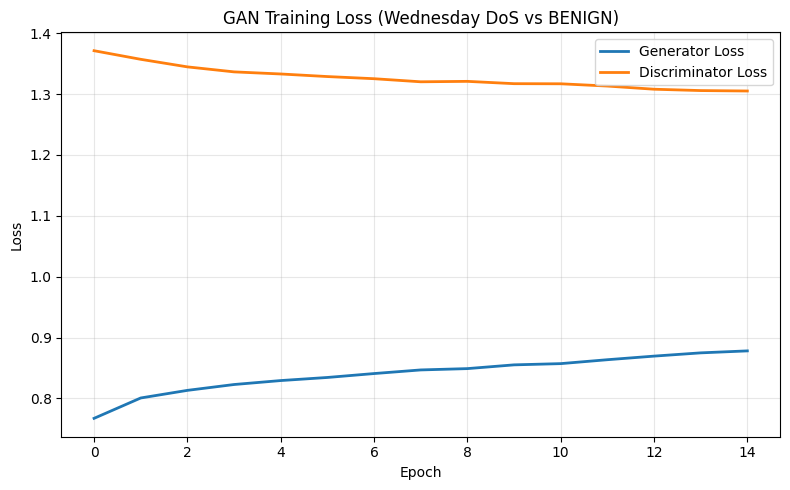

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(g_losses, label="Generator Loss", linewidth=2)
plt.plot(d_losses, label="Discriminator Loss", linewidth=2)

plt.title("GAN Training Loss (Wednesday DoS vs BENIGN)")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Generate synthetic feature vectors

In [27]:
G.eval()

n_samples = len(X_test)

with torch.no_grad():
    z = torch.randn(n_samples, noise_dim).to(device)
    synthetic = G(z).cpu().numpy()

real = X_test
fake = synthetic

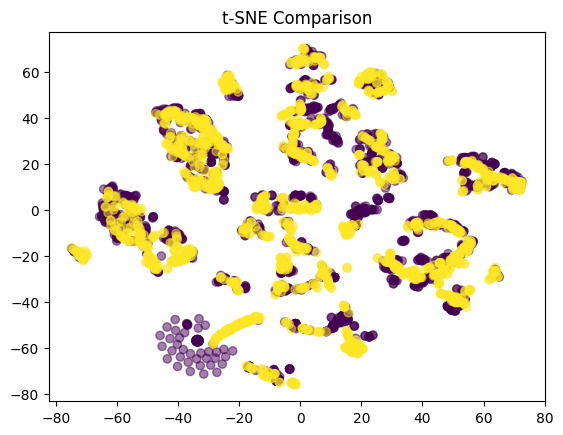

In [30]:
# t-SNE VISUALIZATION
import numpy as np
from sklearn.manifold import TSNE

def plot_tsne(real_data, fake_data, n_samples=2000):

    idx_real = np.random.choice(len(real_data), n_samples, replace=False)
    idx_fake = np.random.choice(len(fake_data), n_samples, replace=False)

    combined = np.vstack([real_data[idx_real], fake_data[idx_fake]])
    labels = np.array([0]*n_samples + [1]*n_samples)

    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    emb = tsne.fit_transform(combined)

    plt.scatter(emb[:, 0], emb[:, 1], c=labels, alpha=0.5)
    plt.title("t-SNE Comparison")
    plt.show()


plot_tsne(real, fake)

## Evaluation (distribution similarity)

In [31]:
## Evaluation (distribution similarity)

print("Feature-wise mean difference:", np.mean(np.abs(real.mean(0) - fake.mean(0))))
print("Feature-wise std difference:", np.mean(np.abs(real.std(0) - fake.std(0))))

from scipy.stats import ks_2samp

ks_scores = [
    ks_2samp(real[:, i], fake[:, i]).statistic
    for i in range(real.shape[1])
]

print("Average KS Statistic:", np.mean(ks_scores))

Feature-wise mean difference: 0.034081277
Feature-wise std difference: 0.27132806
Average KS Statistic: 0.41396073823991303


## Part 2.3: Creative AI – QuickDraw 'Pizza' Subset

In [85]:
# Standard library imports
import os
import json

# Numerical and image processing
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Deep learning framework
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Utilities
from tqdm import tqdm
from scipy.linalg import sqrtm
import requests

In [86]:
# Dataset download
dataset_url = "https://storage.googleapis.com/quickdraw_dataset/full/simplified/pizza.ndjson"

response = requests.get(dataset_url)

file_path = "pizza.ndjson"
with open(file_path, "wb") as f:
    f.write(response.content)

In [87]:
# Load dataset

def extract_valid_drawings(path, max_samples=10000):
    drawings = []

    with open(path, "r") as file:
        for line in file:
            record = json.loads(line)

            if record.get("recognized", False):
                drawings.append(record["drawing"])

            if len(drawings) >= max_samples:
                break

    return drawings


sketch_data = extract_valid_drawings("pizza.ndjson", max_samples=10000)
print(f"Loaded sketches: {len(sketch_data)}")

Loaded sketches: 10000


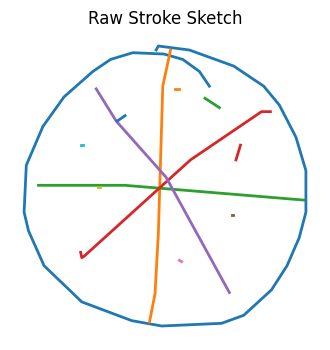

In [90]:
# Visualize stroke data

def plot_stroke_sample(stroke_sample):
    plt.figure(figsize=(4, 4))

    for x_coords, y_coords in stroke_sample:
        plt.plot(x_coords, y_coords, linewidth=2)

    ax = plt.gca()
    ax.invert_yaxis()
    ax.axis("off")
    ax.set_title("Raw Stroke Sketch")

    plt.show()


plot_stroke_sample(sketch_data[3])

In [91]:
# Convert stroke data to image

def strokes_to_image(stroke_data, img_size=28):
    canvas = np.zeros((256, 256), dtype=np.uint8)

    for x_coords, y_coords in stroke_data:
        for i in range(len(x_coords) - 1):
            pt1 = (int(x_coords[i]), int(y_coords[i]))
            pt2 = (int(x_coords[i + 1]), int(y_coords[i + 1]))
            cv2.line(canvas, pt1, pt2, 255, thickness=2)

    resized_img = cv2.resize(canvas, (img_size, img_size))
    return resized_img

In [92]:
# Build dataset tensor

image_set = np.array([strokes_to_image(s) for s in sketch_data])

# Normalize to [-1, 1]
image_set = image_set / 127.5 - 1.0

# Reshape for CNN input (N, C, H, W)
image_set = image_set.reshape(-1, 1, 28, 28)

print(f"Tensor shape: {image_set.shape}")

Tensor shape: (10000, 1, 28, 28)


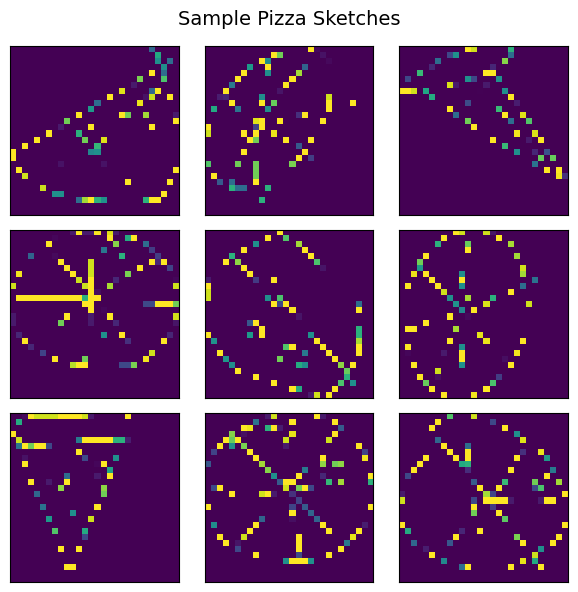

In [93]:
# Grid visualization of samples

def plot_image_grid(data, n=9):
    plt.figure(figsize=(6, 6))
    plt.suptitle("Sample Pizza Sketches", fontsize=14)

    for idx in range(n):
        ax = plt.subplot(3, 3, idx + 1)
        ax.imshow(data[idx][0], cmap="viridis")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(False)

    plt.tight_layout()
    plt.show()


plot_image_grid(image_set)

In [94]:
# Dataset class definition

class SketchDataset(Dataset):
    def __init__(self, samples):
        self.samples = torch.tensor(samples, dtype=torch.float32)

    def __len__(self):
        return self.samples.shape[0]

    def __getitem__(self, index):
        return self.samples[index]


dataset = SketchDataset(image_set)
data_loader = DataLoader(dataset, batch_size=128, shuffle=True)

In [95]:
# Generator network

class Generator(nn.Module):
    def __init__(self, noise_dim=100):
        super().__init__()

        self.model = nn.Sequential(
            nn.ConvTranspose2d(noise_dim, 128, kernel_size=7, stride=1, padding=0),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )

    def forward(self, noise_vector):
        return self.model(noise_vector)

In [96]:
# Discriminator network

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [97]:
# Device setup

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize models
G = Generator().to(device)
D = Discriminator().to(device)

# Loss function
loss_fn = nn.BCELoss()

# Optimizers
optimizer_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

# Latent dimension
latent_dim = 100

In [98]:
# Training loop

num_epochs = 10
gen_losses, disc_losses = [], []

for epoch in range(num_epochs):

    for real_batch in data_loader:

        real_batch = real_batch.to(device)
        batch_size = real_batch.size(0)

        real_labels = torch.ones(batch_size, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        # Train Discriminator

        z = torch.randn(batch_size, latent_dim, 1, 1, device=device)
        fake_batch = G(z)

        loss_real = loss_fn(D(real_batch), real_labels)
        loss_fake = loss_fn(D(fake_batch.detach()), fake_labels)

        d_loss = loss_real + loss_fake

        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        # Train Generator

        z = torch.randn(batch_size, latent_dim, 1, 1, device=device)
        generated_batch = G(z)

        g_loss = loss_fn(D(generated_batch), real_labels)

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

    gen_losses.append(g_loss.item())
    disc_losses.append(d_loss.item())

    print(f"Epoch [{epoch+1}/{num_epochs}] | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

Epoch [1/10] | D Loss: 1.1225 | G Loss: 1.4448
Epoch [2/10] | D Loss: 1.0717 | G Loss: 1.0277
Epoch [3/10] | D Loss: 0.8395 | G Loss: 1.4049
Epoch [4/10] | D Loss: 0.9781 | G Loss: 1.0394
Epoch [5/10] | D Loss: 0.9921 | G Loss: 1.3299
Epoch [6/10] | D Loss: 0.8806 | G Loss: 1.3964
Epoch [7/10] | D Loss: 0.9740 | G Loss: 1.8590
Epoch [8/10] | D Loss: 0.9327 | G Loss: 1.4133
Epoch [9/10] | D Loss: 1.3100 | G Loss: 0.7778
Epoch [10/10] | D Loss: 1.0243 | G Loss: 1.3644


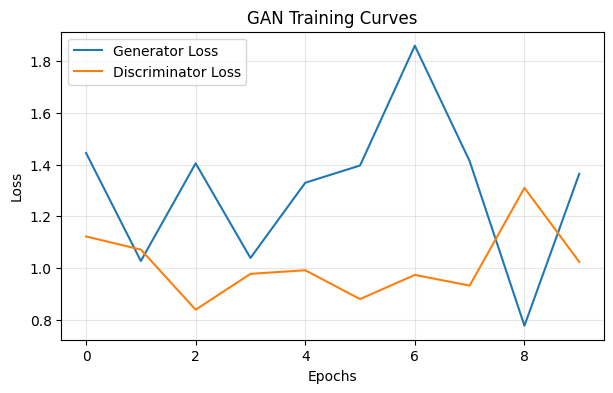

In [101]:
# Loss visualization

plt.figure(figsize=(7, 4))

plt.plot(gen_losses, label="Generator Loss")
plt.plot(disc_losses, label="Discriminator Loss")

plt.title("GAN Training Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

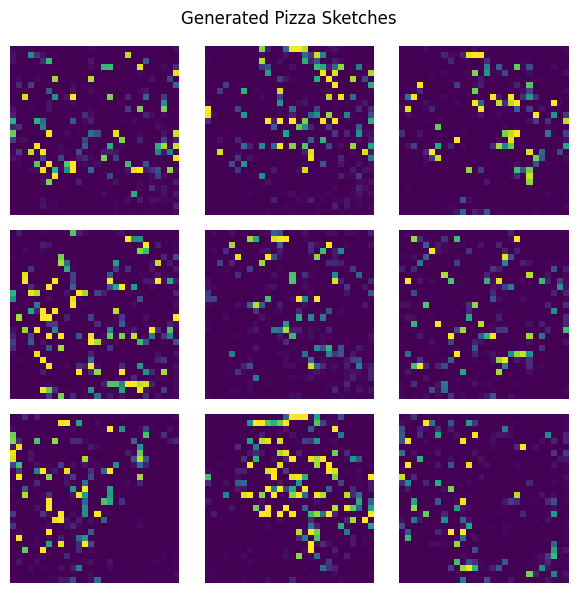

In [ ]:
# Generate samples from generator

def visualize_generated_samples(generator, num_samples=9):
    generator.eval()

    z = torch.randn(num_samples, latent_dim, 1, 1, device=device)

    with torch.no_grad():
        fake_samples = generator(z).cpu()

    plt.figure(figsize=(6, 6))
    plt.suptitle("Generated Pizza Sketches")

    for idx in range(num_samples):
        ax = plt.subplot(3, 3, idx + 1)
        ax.imshow(fake_samples[idx][0], cmap="viridis")
        ax.axis("off")

    plt.tight_layout()
    plt.show()


visualize_generated_samples(G)

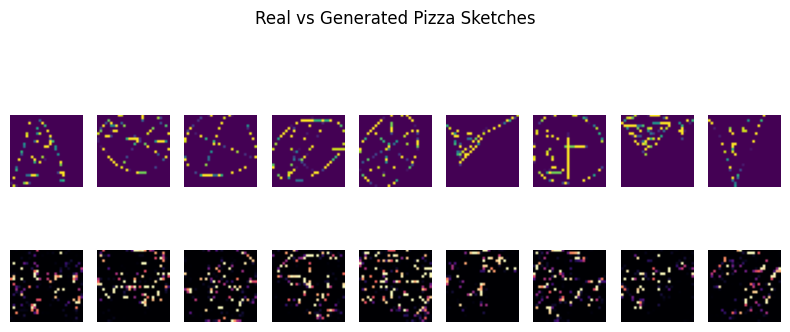

In [107]:
# Real vs Fake comparison

def compare_real_vs_fake(generator, dataloader, num_samples=9):

    real_samples = next(iter(dataloader)).to(device)

    z = torch.randn(num_samples, latent_dim, 1, 1, device=device)

    with torch.no_grad():
        fake_samples = generator(z).cpu()

    real_samples = real_samples.cpu()

    plt.figure(figsize=(8, 4))
    plt.suptitle("Real vs Generated Pizza Sketches")

    for idx in range(num_samples):

        # Real images
        ax_real = plt.subplot(2, num_samples, idx + 1)
        ax_real.imshow(real_samples[idx][0], cmap="viridis")
        ax_real.axis("off")

        # Generated images
        ax_fake = plt.subplot(2, num_samples, idx + 1 + num_samples)
        ax_fake.imshow(fake_samples[idx][0], cmap="magma")
        ax_fake.axis("off")

    plt.tight_layout()
    plt.show()


compare_real_vs_fake(G, data_loader)